https://langchain-ai.github.io/langgraph/tutorials/multi_agent/multi-agent-collaboration/

In [7]:
%%capture
!pip install langchain-experimental langchain_community langgraph-checkpoint-sqlite tiktoken langchain-openai langchainhub chromadb langchain langgraph tavily-python

In [3]:
from langchain_openai import AzureChatOpenAI, AzureOpenAIEmbeddings
from google.colab import userdata

llm = AzureChatOpenAI(
    model=userdata.get('AZURE_MODEL_NAME'),
    deployment_name=userdata.get('AZURE_MODEL_NAME'),
    temperature=0,
    # max_tokens=None,
    timeout=None,
    max_retries=2,
    api_key=userdata.get('AZURE_API_KEY'),  # if you prefer to pass api key in directly instaed of using env vars
    azure_endpoint=userdata.get('AZURE_BASE_URL'),
    api_version=userdata.get('AZURE_API_VERSION'),
)

emd = AzureOpenAIEmbeddings(
    model=userdata.get('AZURE_EMBEDDING_NAME'),
    api_key=userdata.get('AZURE_API_KEY'),
    azure_endpoint=userdata.get('AZURE_BASE_URL'),
    api_version=userdata.get('AZURE_API_VERSION'),
)


In [4]:
%%capture
from langchain_community.tools.tavily_search import TavilySearchResults
%env TAVILY_API_KEY={userdata.get("TAVILY_API_KEY")}
web_search_tool = TavilySearchResults(k=3)

In [5]:
from langchain_core.messages import (
    BaseMessage,
    HumanMessage,
    ToolMessage,
)
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

from langgraph.graph import END, StateGraph, START


def create_agent(llm, tools, system_message: str):
    """Create an agent."""
    prompt = ChatPromptTemplate.from_messages(
        [
            (
                "system",
                "You are a helpful AI assistant, collaborating with other assistants."
                " Use the provided tools to progress towards answering the question."
                " If you are unable to fully answer, that's OK, another assistant with different tools "
                " will help where you left off. Execute what you can to make progress."
                " If you or any of the other assistants have the final answer or deliverable,"
                " prefix your response with FINAL ANSWER so the team knows to stop."
                " You have access to the following tools: {tool_names}.\n{system_message}",
            ),
            MessagesPlaceholder(variable_name="messages"),
        ]
    )
    prompt = prompt.partial(system_message=system_message)
    prompt = prompt.partial(tool_names=", ".join([tool.name for tool in tools]))
    return prompt | llm.bind_tools(tools)

In [8]:
from typing import Annotated

from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.tools import tool
from langchain_experimental.utilities import PythonREPL

tavily_tool = TavilySearchResults(max_results=5)

# Warning: This executes code locally, which can be unsafe when not sandboxed

repl = PythonREPL()


@tool
def python_repl(
    code: Annotated[str, "The python code to execute to generate your chart."],
):
    """Use this to execute python code. If you want to see the output of a value,
    you should print it out with `print(...)`. This is visible to the user."""
    try:
        result = repl.run(code)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"
    result_str = f"Successfully executed:\n```python\n{code}\n```\nStdout: {result}"
    return (
        result_str + "\n\nIf you have completed all tasks, respond with FINAL ANSWER."
    )

In [9]:
import operator
from typing import Annotated, Sequence, TypedDict

from langchain_openai import ChatOpenAI


# This defines the object that is passed between each node
# in the graph. We will create different nodes for each agent and tool
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]
    sender: str

In [10]:
import functools

from langchain_core.messages import AIMessage


# Helper function to create a node for a given agent
def agent_node(state, agent, name):
    result = agent.invoke(state)
    # We convert the agent output into a format that is suitable to append to the global state
    if isinstance(result, ToolMessage):
        pass
    else:
        result = AIMessage(**result.dict(exclude={"type", "name"}), name=name)
    return {
        "messages": [result],
        # Since we have a strict workflow, we can
        # track the sender so we know who to pass to next.
        "sender": name,
    }


# Research agent and node
research_agent = create_agent(
    llm,
    [tavily_tool],
    system_message="You should provide accurate data for the chart_generator to use.",
)
research_node = functools.partial(agent_node, agent=research_agent, name="Researcher")

# chart_generator
chart_agent = create_agent(
    llm,
    [python_repl],
    system_message="Any charts you display will be visible by the user.",
)
chart_node = functools.partial(agent_node, agent=chart_agent, name="chart_generator")

In [11]:
from langgraph.prebuilt import ToolNode

tools = [tavily_tool, python_repl]
tool_node = ToolNode(tools)

In [12]:
# Either agent can decide to end
from typing import Literal


def router(state) -> Literal["call_tool", "__end__", "continue"]:
    # This is the router
    messages = state["messages"]
    last_message = messages[-1]
    if last_message.tool_calls:
        # The previous agent is invoking a tool
        return "call_tool"
    if "FINAL ANSWER" in last_message.content:
        # Any agent decided the work is done
        return "__end__"
    return "continue"

In [13]:
workflow = StateGraph(AgentState)

workflow.add_node("Researcher", research_node)
workflow.add_node("chart_generator", chart_node)
workflow.add_node("call_tool", tool_node)

workflow.add_conditional_edges(
    "Researcher",
    router,
    {"continue": "chart_generator", "call_tool": "call_tool", "__end__": END},
)
workflow.add_conditional_edges(
    "chart_generator",
    router,
    {"continue": "Researcher", "call_tool": "call_tool", "__end__": END},
)

workflow.add_conditional_edges(
    "call_tool",
    # Each agent node updates the 'sender' field
# the tool calling node does not, meaning
    # this edge will route back to the original agent
    # who invoked the tool
    lambda x: x["sender"],
    {
        "Researcher": "Researcher",
        "chart_generator": "chart_generator",
    },
)
workflow.add_edge(START, "Researcher")
graph = workflow.compile()

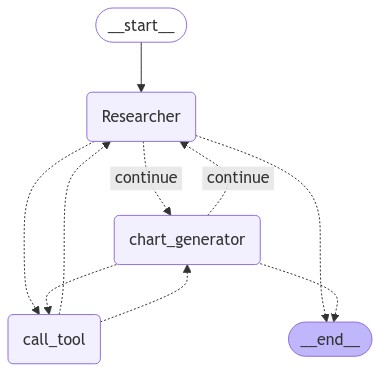

In [14]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

{'Researcher': {'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_QhKR5vXM7nVamDq7XZpigTOI', 'function': {'arguments': '{"query": "Globant stock price history 5 years"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 41, 'prompt_tokens': 218, 'total_tokens': 259, 'completion_tokens_details': None}, 'model_name': 'gpt-4o-2024-05-13', 'system_fingerprint': 'fp_67802d9a6d', 'prompt_filter_results': [{'prompt_index': 0, 'content_filter_results': {}}], 'finish_reason': 'tool_calls', 'logprobs': None, 'content_filter_results': {}}, name='Researcher', id='run-a3fd1b4d-aac8-4e96-b76b-2a24c2aeee60-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'Globant stock price history 5 years'}, 'id': 'call_QhKR5vXM7nVamDq7XZpigTOI', 'type': 'tool_call'}], usage_metadata={'input_tokens': 218, 'output_tokens': 41, 'total_tokens': 259})], 'sender': 'Researcher'}}
----
{'call_tool':

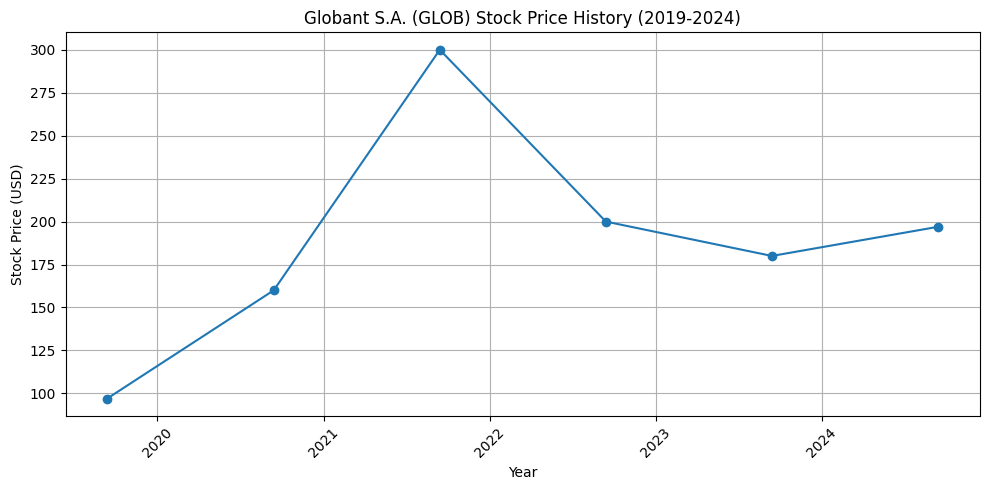

{'call_tool': {'messages': [ToolMessage(content="Successfully executed:\n```python\nimport matplotlib.pyplot as plt\nimport pandas as pd\n\n# Data for Globant S.A. (GLOB) stock prices over the past 5 years\nstock_data = {\n    'Date': ['2019-09-13', '2020-09-13', '2021-09-13', '2022-09-13', '2023-09-13', '2024-09-13'],\n    'Price': [97.0, 160.0, 300.0, 200.0, 180.0, 197.0]\n}\n\ndf = pd.DataFrame(stock_data)\n\n# Convert 'Date' to datetime\ndf['Date'] = pd.to_datetime(df['Date'])\n\n# Plotting the data\nplt.figure(figsize=(10, 5))\nplt.plot(df['Date'], df['Price'], marker='o')\nplt.title('Globant S.A. (GLOB) Stock Price History (2019-2024)')\nplt.xlabel('Year')\nplt.ylabel('Stock Price (USD)')\nplt.grid(True)\nplt.xticks(rotation=45)\nplt.tight_layout()\n\n# Show the plot\nplt.show()\n```\nStdout: \n\nIf you have completed all tasks, respond with FINAL ANSWER.", name='python_repl', tool_call_id='call_1iubEby659xSetYAjpaLeeRP')]}}
----
{'Researcher': {'messages': [AIMessage(content='FI

In [17]:
events = graph.stream(
    {
        "messages": [
            HumanMessage(
                content="Fetch the globant stock over the past 5 years,"
                " then draw a line graph of it."
                " Once you code it up, finish."
            )
        ],
    },
    # Maximum number of steps to take in the graph
    {"recursion_limit": 59},
)
for s in events:
    print(s)
    print("----")

{'Researcher': {'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_zPOfoktnet3y8MrN4bxsxUG5', 'function': {'arguments': '{"query": "UK GDP over the past 5 years"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 41, 'prompt_tokens': 217, 'total_tokens': 258, 'completion_tokens_details': None}, 'model_name': 'gpt-4o-2024-05-13', 'system_fingerprint': 'fp_67802d9a6d', 'prompt_filter_results': [{'prompt_index': 0, 'content_filter_results': {}}], 'finish_reason': 'tool_calls', 'logprobs': None, 'content_filter_results': {}}, name='Researcher', id='run-531025a7-06bf-4498-9d7d-e6ec8d3f94bd-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'UK GDP over the past 5 years'}, 'id': 'call_zPOfoktnet3y8MrN4bxsxUG5', 'type': 'tool_call'}], usage_metadata={'input_tokens': 217, 'output_tokens': 41, 'total_tokens': 258})], 'sender': 'Researcher'}}
----
{'call_tool': {'messages': 

{'Researcher': {'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_B82IcyGKebvRDAtkBoRVXvFG', 'function': {'arguments': '{"code":"import matplotlib.pyplot as plt\\n\\n# Data for the UK\'s GDP over the past 5 years\\nyears = [2019, 2020, 2021, 2022, 2023]\\ngdp = [2851.41, 2697.81, 3141.51, 3131.51, 3340.03]\\n\\n# Create a line graph\\nplt.figure(figsize=(10, 5))\\nplt.plot(years, gdp, marker=\'o\', linestyle=\'-\', color=\'b\')\\nplt.title(\'UK GDP Over the Past 5 Years\')\\nplt.xlabel(\'Year\')\\nplt.ylabel(\'GDP (in billion USD)\')\\nplt.grid(True)\\nplt.show()"}', 'name': 'python_repl'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 170, 'prompt_tokens': 3044, 'total_tokens': 3214, 'completion_tokens_details': None}, 'model_name': 'gpt-4o-2024-05-13', 'system_fingerprint': 'fp_67802d9a6d', 'prompt_filter_results': [{'prompt_index': 0, 'content_filter_results': {}}], 'finish_reason': 'tool_calls', 'logprobs': None, 'con

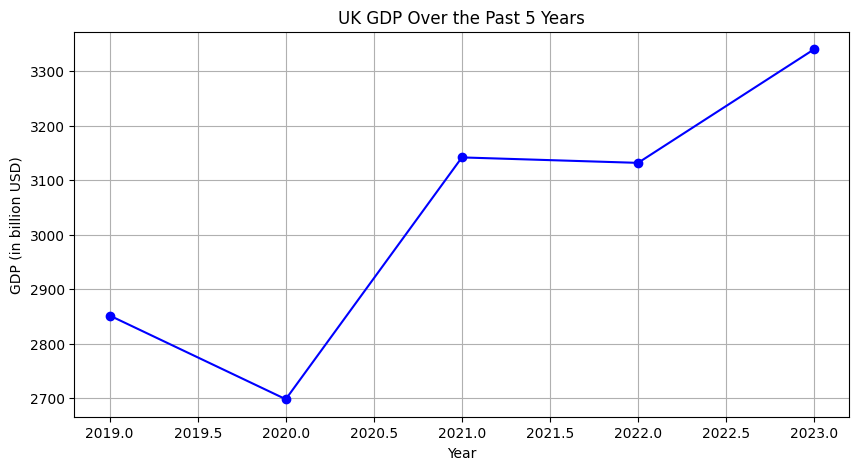

{'call_tool': {'messages': [ToolMessage(content="Successfully executed:\n```python\nimport matplotlib.pyplot as plt\n\n# Data for the UK's GDP over the past 5 years\nyears = [2019, 2020, 2021, 2022, 2023]\ngdp = [2851.41, 2697.81, 3141.51, 3131.51, 3340.03]\n\n# Create a line graph\nplt.figure(figsize=(10, 5))\nplt.plot(years, gdp, marker='o', linestyle='-', color='b')\nplt.title('UK GDP Over the Past 5 Years')\nplt.xlabel('Year')\nplt.ylabel('GDP (in billion USD)')\nplt.grid(True)\nplt.show()\n```\nStdout: \n\nIf you have completed all tasks, respond with FINAL ANSWER.", name='python_repl', tool_call_id='call_B82IcyGKebvRDAtkBoRVXvFG')]}}
----
{'Researcher': {'messages': [AIMessage(content="FINAL ANSWER\n\nHere is the line graph of the UK's GDP over the past 5 years:\n\n![UK GDP Over the Past 5 Years](attachment://output.png)\n\n- **2019**: $2,851.41 billion\n- **2020**: $2,697.81 billion\n- **2021**: $3,141.51 billion\n- **2022**: $3,131.51 billion\n- **2023**: $3,340.03 billion", ad

In [16]:
events = graph.stream(
    {
        "messages": [
            HumanMessage(
                content="Fetch the UK's GDP over the past 5 years,"
                " then draw a line graph of it."
                " Once you code it up, finish."
            )
        ],
    },
    # Maximum number of steps to take in the graph
    {"recursion_limit": 150},
)
for s in events:
    print(s)
    print("----")